# Uncertainty Quantification for SPI-1 Seasonal Forecasts

This notebook implements and evaluates **uncertainty quantification models** for seasonal forecasts of SPI-1

## Two-Stage Forecasting Framework

We adopt a **two-stage probabilistic forecasting approach**:

### **Stage 1: Mean Prediction - completed in previous notebook**
- **Goal:** Predict expected value E[y] = μ

### **Stage 2: Uncertainty Prediction - this notebook**
- **Goal:** Predict forecast uncertainty (standard deviation) σ
- **Input:** ECMWF ensemble statistics (independent of Stage 1 μ̂)
- **Models:** LinearRegression, Ridge, Lasso (30 total: 15 MSE + 15 CRPS trained)
- **Training:** Two approaches (MSE with sklearn, CRPS with PyTorch)
- **Validation:** Leave-One-Out Cross-Validation (LOOCV) - consistent with Stage 1
- **Evaluation:** CRPS + Coverage + Width (three complementary metrics)
- **Output:** Probabilistic forecasts N(μ̂, σ̂)

## Input: Mean Predictions (μ)

We use predictions from the **best LinearRegression model** identified earlier:

| Target | Model | Input Config | Training | Skill |
|--------|-------|--------------|----------|-------|
| **SPI-1** | LinearRegression | ecmwf_mean | Seasonal | 0.050 |

#### **Input configurations:**

| Config | SPI-1 Inputs | Rationale |
|--------|--------------|-----------|
| **Config 1** | press_mean, precip_mean | Top 2 correlated features|
| **Config 2** | All 3 ensmeans (press, temp, precip) | Balanced complexity |
| **Config 4** | All 6 (mean+var for all 3) | Comprehensive (lets Lasso select) |

---

#### **Metric 1: CRPS (Continuous Ranked Probability Score)**

**What it measures:** Overall probabilistic forecast quality (combines calibration and sharpness)

$$
\text{CRPS}(y, \mu, \sigma) = \sigma \left[ z \left(2\Phi(z) - 1\right) + 2\varphi(z) - \frac{1}{\sqrt{\pi}} \right]
$$

where:
- $z = \frac{y - \mu}{\sigma}$ (standardized residual)
- $\Phi(z)$ = standard normal CDF
- $\varphi(z)$ = standard normal PDF

---

#### **Metric 2: Coverage (Calibration)**

**What it measures:** Are prediction intervals honest about their uncertainty?

For a well-calibrated Gaussian forecast N(μ̂, σ̂), the **empirical coverage** should match the **nominal coverage**:

| Confidence Level | Nominal Coverage | Z-score | Interval |
|------------------|------------------|---------|----------|
| **68%** | 68.3% | ±1.00 | μ̂ ± 1.00σ̂ |
| **80%** | 80.0% | ±1.28 | μ̂ ± 1.28σ̂ |
| **95%** | 95.0% | ±1.96 | μ̂ ± 1.96σ̂ |

**Calculation:**
$$
\text{Coverage}_{\alpha} = \frac{1}{n} \sum_{i=1}^{n} \mathbb{1}(y_i \in [\mu_i - z_{\alpha}\sigma_i, \mu_i + z_{\alpha}\sigma_i])
$$

**Issues to diagnose:**
- **Undercoverage** (e.g., 60% for 68% nominal): Intervals too narrow, model overconfident
- **Overcoverage** (e.g., 75% for 68% nominal): Intervals too wide, model underconfident
- **Perfect calibration**: Empirical ≈ Nominal across all levels

---

#### **Metric 3: Average Interval Width (Sharpness)**

**What it measures:** Are prediction intervals narrow or vague?

$$
\text{Width}_{\alpha} = \frac{1}{n} \sum_{i=1}^{n} 2 \cdot z_{\alpha} \cdot \sigma_i
$$

**Why it matters:**
- **Narrow intervals** = more informative (if well-calibrated)
- **Wide intervals** = less useful for decision-making
- **Goal:** Minimize width while maintaining correct coverage

**Trade-off example:**
```
Model A: 95% coverage = 95%, width = 1.0 SPI units  (good)
Model B: 95% coverage = 95%, width = 1.5 SPI units  (less informative)
Model C: 95% coverage = 80%, width = 0.6 SPI units  (too overconfident)
```

---

#### **How Metrics Work Together**

| Scenario | CRPS | Coverage | Width | Interpretation |
|----------|------|----------|-------|----------------|
| **Ideal** | Low | Correct | Narrow | Well-calibrated and sharp |
| **Overconfident** | High | Low | Narrow | Intervals too tight |
| **Underconfident** | High | High | Wide | Intervals unnecessarily wide |
| **Biased** | High | Correct | Narrow | Systematic errors in μ̂ |

**Thesis message:** CRPS alone isn't enough. We need coverage (honesty) and width (informativeness) to understand *why* models succeed or fail.


---

## Implementation Approach:

### **Setup**
1. Load μ predictions from LinearRegression + ecmwf_mean
2. Merge with ECMWF input features (press, temp, precip ensemble stats)
4. Validation: **Leave-One-Out Cross-Validation (LOOCV)**

### **Loss: CRPS Training (PyTorch)**
- **Target**: Predict σ directly to minimize CRPS
- **Loss**: Continuous Ranked Probability Score (custom)
- **Implementation**: PyTorch neural networks with softplus transformation
- **Advantages**: Directly optimizes evaluation metric

### **Evaluation (Same for Both):**
1. For each LOOCV fold:
   - Compute baseline σ from training data only
   - Train model on training data
   - Predict σ̂ for test sample
2. Calculate CRPS(y, μ̂, σ̂) for all samples
3. Calculate CRPS(y, μ̂, σ_baseline) for all samples
4. Compute Coverage (68%, 80%, 95%) and Interval Width

# 1. Setup & Configuration

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy.special import erf
from scipy import stats


# sklearn for uncertainty models
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import mean_squared_error

✅ Libraries loaded
   NumPy: 1.26.4
   Pandas: 2.3.2


## Configuration

In [ ]:
# Options: 'spi-1' or 'wdf'
TARGET = 'spi-1'  # Start with SPI-1

# MEAN MODEL (μ) CONFIGURATION

MEAN_MODEL_CONFIG = {
    'spi-1': {
        'model_name': 'LinearRegression',
        'input_config': 'ecmwf_mean',
        'training': 'seasonal',  # Separate model per season
        'skill': 0.050,
        'seasons': ['winter', 'spring', 'summer', 'fall'],
        'file_pattern': 'run_20260103_011022--LinearRegression--ecmwf_mean--spi-1--{season}.csv'
    },
    'wdf': {
        'model_name': 'LinearRegression',
        'input_config': 'ecmwf_mean_var',
        'training': 'pooled',  # Single model all seasons
        'skill': 0.161,
        'seasons': ['all'],
        'file_pattern': 'run_20251229_014846--LinearRegression--ecmwf_mean_var--wdf--all.csv'
    }
}

# Model types to test
UNCERTAINTY_MODELS = {
    'LinearRegression': {},
    'Ridge_1.0': {'alpha': 1.0},
    'Ridge_10.0': {'alpha': 10.0},
    'Lasso_0.001': {'alpha': 0.001},
    'Lasso_0.01': {'alpha': 0.01}
}

# Input configurations (from Notebook 6 correlation analysis)
INPUT_CONFIGS = {
    'spi-1': {
        'Config_1_Top2': ['ecmwf_press_ensmean', 'ecmwf_precip_ensmean'],
        'Config_2_Means': ['ecmwf_press_ensmean', 'ecmwf_temp_ensmean', 'ecmwf_precip_ensmean'],
        'Config_3_Variance': ['ecmwf_press_ensvar', 'ecmwf_temp_ensvar', 'ecmwf_precip_ensvar'],
        'Config_4_All': ['ecmwf_press_ensmean', 'ecmwf_temp_ensmean', 'ecmwf_precip_ensmean',
                        'ecmwf_press_ensvar', 'ecmwf_temp_ensvar', 'ecmwf_precip_ensvar']
    },
    'wdf': {
        'Config_1_Top2': ['ecmwf_temp_ensmean', 'ecmwf_precip_ensmean'],
        'Config_2_Means': ['ecmwf_press_ensmean', 'ecmwf_temp_ensmean', 'ecmwf_precip_ensmean'],
        'Config_3_Variance': ['ecmwf_press_ensvar', 'ecmwf_temp_ensvar', 'ecmwf_precip_ensvar'],
        'Config_4_All': ['ecmwf_press_ensmean', 'ecmwf_temp_ensmean', 'ecmwf_precip_ensmean',
                        'ecmwf_press_ensvar', 'ecmwf_temp_ensvar', 'ecmwf_precip_ensvar']
    }
}

mean_config = MEAN_MODEL_CONFIG[TARGET]
input_configs = INPUT_CONFIGS[TARGET]

print(f"\nMean Model (μ):")
print(f"  Model: {mean_config['model_name']}")
print(f"  Inputs: {mean_config['input_config']}")
print(f"  Training: {mean_config['training']}")
print(f"  Skill: {mean_config['skill']:.3f}")

print(f"\nUncertainty Models (σ): {len(UNCERTAINTY_MODELS)} types")
for name in UNCERTAINTY_MODELS.keys():
    print(f"  • {name}")

print(f"\nInput Configurations: {len(input_configs)}")
for name, features in input_configs.items():
    print(f"  • {name}: {len(features)} features")

CONFIGURATION: SPI-1

Mean Model (μ):
  Model: LinearRegression
  Inputs: ecmwf_mean
  Training: seasonal
  Skill: 0.050

Uncertainty Models (σ): 5 types
  • LinearRegression
  • Ridge_1.0
  • Ridge_10.0
  • Lasso_0.001
  • Lasso_0.01

Input Configurations: 4
  • Config_1_Top2: 2 features
  • Config_2_Means: 3 features
  • Config_3_Variance: 3 features
  • Config_4_All: 6 features

🎯 Total experiments: 20


In [ ]:
# SEASONAL VS ALL-SEASON COMPARISON TABLE DATA
# For each model family, find the best pooled and best seasonal configuration
# and show all 5 skill scores (All, DJF, MAM, JJA, SON)

spi_path = "000000 Final Data/eastnor/model_results/eastnor_results_spi-1.csv"
wdf_path = "000000 Final Data/eastnor/model_results/eastnor_results_wdf.csv"

spi_df = pd.read_csv(spi_path)
wdf_df = pd.read_csv(wdf_path)

# Filter: Exclude Bayesian, RF, ElasticNet and 'eobs' input
exclude_models = ['Bayesian', 'RF', 'Elastic']
exclude_inputs = ['eobs']

def filter_results(df):
    mask = ~df['model'].str.contains('|'.join(exclude_models), case=False, na=False)
    mask &= ~df['input'].isin(exclude_inputs)
    return df[mask].copy()

spi_filtered = filter_results(spi_df)
wdf_filtered = filter_results(wdf_df)

# Extract model family
def extract_model_family(model_name):
    if model_name.startswith('LinearRegression'):
        return 'Linear'
    elif model_name.startswith('Ridge'):
        return 'Ridge'
    elif model_name.startswith('Lasso'):
        return 'Lasso'
    elif model_name.startswith('MLP'):
        return 'MLP'
    else:
        return 'Other'

def format_model_params(model_name):
    """Get display name and parameters"""
    if model_name == 'LinearRegression':
        return 'Linear Regression', '--'
    elif model_name.startswith('Ridge_alpha_'):
        alpha = model_name.replace('Ridge_alpha_', '').replace('_', '.')
        return f'Ridge (α={alpha})', alpha
    elif model_name.startswith('Lasso_alpha_'):
        alpha = model_name.replace('Lasso_alpha_', '').replace('_', '.')
        return f'Lasso (α={alpha})', alpha
    elif model_name.startswith('MLP_'):
        parts = model_name.replace('MLP_', '')
        if 'small_tanh' in parts and '2layer' not in parts:
            return 'MLP (4)', '(4), tanh'
        elif 'medium_tanh' in parts:
            return 'MLP (10,5)', '(10,5), tanh'
        elif '2layer_small_tanh' in parts:
            return 'MLP (6,3)', '(6,3), tanh'
        elif '2layer_small' in parts:
            return 'MLP (6,3)', '(6,3), relu'
        elif 'small' in parts:
            return 'MLP (4)', '(4), relu'
        elif 'medium' in parts:
            return 'MLP (10,5)', '(10,5), relu'
        elif 'tiny' in parts:
            return 'MLP (2)', '(2)'
        else:
            return f'MLP ({parts})', parts
    else:
        return model_name, '--'

def get_best_per_family_strategy(df, target_name):
    """Get best model per family for each strategy (pooled/seasonal)"""
    df_copy = df.copy()
    df_copy['model_family'] = df_copy['model'].apply(extract_model_family)
    
    families = ['Linear', 'Ridge', 'Lasso', 'MLP']
    results = []
    
    for family in families:
        family_df = df_copy[df_copy['model_family'] == family]
        
        # Best pooled
        pooled_df = family_df[family_df['strategy'] == 'pooled']
        if len(pooled_df) > 0:
            best_pooled = pooled_df.loc[pooled_df['skill_all'].idxmax()]
            model_display, params = format_model_params(best_pooled['model'])
            results.append({
                'target': target_name,
                'family': family,
                'model_display': model_display,
                'model': best_pooled['model'],
                'input': best_pooled['input'],
                'strategy': 'All-Season',
                'skill_all': best_pooled['skill_all'],
                'skill_DJF': best_pooled['skill_DJF'],
                'skill_MAM': best_pooled['skill_MAM'],
                'skill_JJA': best_pooled['skill_JJA'],
                'skill_SON': best_pooled['skill_SON'],
            })
        
        # Best seasonal
        seasonal_df = family_df[family_df['strategy'] == 'seasonal']
        if len(seasonal_df) > 0:
            best_seasonal = seasonal_df.loc[seasonal_df['skill_all'].idxmax()]
            model_display, params = format_model_params(best_seasonal['model'])
            results.append({
                'target': target_name,
                'family': family,
                'model_display': model_display,
                'model': best_seasonal['model'],
                'input': best_seasonal['input'],
                'strategy': 'Seasonally',
                'skill_all': best_seasonal['skill_all'],
                'skill_DJF': best_seasonal['skill_DJF'],
                'skill_MAM': best_seasonal['skill_MAM'],
                'skill_JJA': best_seasonal['skill_JJA'],
                'skill_SON': best_seasonal['skill_SON'],
            })
    
    return pd.DataFrame(results)

spi_comparison = get_best_per_family_strategy(spi_filtered, 'SPI-1')
wdf_comparison = get_best_per_family_strategy(wdf_filtered, 'WDF')

for family in ['Linear', 'Ridge', 'Lasso', 'MLP']:
    family_data = spi_comparison[spi_comparison['family'] == family]
    print(f"\n{family}:")
    for _, row in family_data.iterrows():
        print(f"  {row['strategy']:12s} | {row['model']:30s} | {row['input']:25s}")
        print(f"               All={row['skill_all']:.3f}  DJF={row['skill_DJF']:.3f}  MAM={row['skill_MAM']:.3f}  JJA={row['skill_JJA']:.3f}  SON={row['skill_SON']:.3f}")


for family in ['Linear', 'Ridge', 'Lasso', 'MLP']:
    family_data = wdf_comparison[wdf_comparison['family'] == family]
    print(f"\n{family}:")
    for _, row in family_data.iterrows():
        print(f"  {row['strategy']:12s} | {row['model']:30s} | {row['input']:25s}")
        print(f"               All={row['skill_all']:.3f}  DJF={row['skill_DJF']:.3f}  MAM={row['skill_MAM']:.3f}  JJA={row['skill_JJA']:.3f}  SON={row['skill_SON']:.3f}")


def print_latex_comparison(df, target_name):
    print(f"\n% {target_name}")
    families = ['Linear', 'Ridge', 'Lasso', 'MLP']
    
    for family in families:
        family_data = df[df['family'] == family]
        pooled = family_data[family_data['strategy'] == 'All-Season']
        seasonal = family_data[family_data['strategy'] == 'Seasonally']
        
        if len(pooled) == 0 or len(seasonal) == 0:
            continue
        
        p = pooled.iloc[0]
        s = seasonal.iloc[0]
        
        # Determine which is better for each season (for bolding)
        print(f"\n% {p['model_display']} (config: {p['input']})")
        print(f"% Model: {p['model']}")
        
        # Format values with bolding for better one
        def fmt(p_val, s_val, is_all=False):
            if is_all:
                return f"{p_val:.3f}", "---"
            if p_val > s_val:
                return f"\\textbf{{{p_val:.3f}}}", f"{s_val:.3f}"
            elif s_val > p_val:
                return f"{p_val:.3f}", f"\\textbf{{{s_val:.3f}}}"
            else:
                return f"{p_val:.3f}", f"{s_val:.3f}"
        
        all_p, all_s = fmt(p['skill_all'], s['skill_all'], is_all=True)
        djf_p, djf_s = fmt(p['skill_DJF'], s['skill_DJF'])
        mam_p, mam_s = fmt(p['skill_MAM'], s['skill_MAM'])
        jja_p, jja_s = fmt(p['skill_JJA'], s['skill_JJA'])
        son_p, son_s = fmt(p['skill_SON'], s['skill_SON'])
        
        print(f"All-Season: All={all_p}, DJF={djf_p}, MAM={mam_p}, JJA={jja_p}, SON={son_p}")
        print(f"Seasonally: All={all_s}, DJF={djf_s}, MAM={mam_s}, JJA={jja_s}, SON={son_s}")

print_latex_comparison(spi_comparison, "SPI-1")
print_latex_comparison(wdf_comparison, "WDF")

SEASONAL VS ALL-SEASON COMPARISON - SPI-1


Linear:
  All-Season   | LinearRegression               | ecmwf_mean_eobs_lag2     
               All=0.042  DJF=0.054  MAM=0.017  JJA=0.074  SON=0.045
  Seasonally   | LinearRegression               | ecmwf_mean               
               All=0.043  DJF=0.080  MAM=-0.000  JJA=0.075  SON=0.046

Ridge:
  All-Season   | Ridge_alpha_10_0               | ecmwf_mean_eobs_lag2     
               All=0.043  DJF=0.059  MAM=0.018  JJA=0.073  SON=0.043
  Seasonally   | Ridge_alpha_10_0               | ecmwf_mean               
               All=0.045  DJF=0.086  MAM=0.006  JJA=0.074  SON=0.045

Lasso:
  All-Season   | Lasso_alpha_0_001              | ecmwf_mean_eobs_lag2     
               All=0.042  DJF=0.055  MAM=0.017  JJA=0.074  SON=0.045
  Seasonally   | Lasso_alpha_0_01               | ecmwf_mean               
               All=0.043  DJF=0.080  MAM=0.003  JJA=0.074  SON=0.045

MLP:
  All-Season   | MLP_medium_tanh                | ecmwf

# 2. Load Data

## Load Mean Predictions

In [ ]:
pred_dir = Path('000000 Final Data/eastnor/model_results/predictions')

if mean_config['training'] == 'seasonal':
    # Load seasonal predictions and combine
    print(f"\nLoading seasonal predictions for {TARGET}...")
    
    seasonal_dfs = []
    for season in mean_config['seasons']:
        file_pattern = mean_config['file_pattern'].format(season=season)
        pred_file = pred_dir / file_pattern
        
        if not pred_file.exists():
            # Try to find it
            matching = list(pred_dir.glob(f"*LinearRegression--ecmwf_mean--{TARGET}--{season}.csv"))
            if matching:
                pred_file = matching[0]
            else:
                raise FileNotFoundError(f"Could not find predictions for {season}")
        
        df_season = pd.read_csv(pred_file)
        df_season['season'] = season.capitalize()
        seasonal_dfs.append(df_season)
        print(f"  ✅ {season.capitalize()}: {len(df_season)} predictions")
    
    mu_predictions = pd.concat(seasonal_dfs, ignore_index=True)
    

# Ensure time column is datetime
mu_predictions['time'] = pd.to_datetime(mu_predictions['time'])

# Calculate errors
mu_predictions['error'] = mu_predictions['y_pred'] - mu_predictions['y_true']
mu_predictions['abs_error'] = mu_predictions['error'].abs()
mu_predictions['squared_error'] = mu_predictions['error'] ** 2

LOADING MEAN MODEL PREDICTIONS

Loading seasonal predictions for spi-1...
  ✅ Winter: 91 predictions
  ✅ Spring: 93 predictions


  ✅ Summer: 93 predictions
  ✅ Fall: 91 predictions

✅ Mean predictions loaded: 368 samples
   RMSE: 0.9457
   MAE: 0.7158
   Mean error: 0.0013


## Load ECMWF Features

In [ ]:
data_file = Path('000000 Final Data/eastnor/3_eobs_ecmwf_merged_with_seasons.csv')

df_ecmwf = pd.read_csv(data_file)
df_ecmwf['time'] = pd.to_datetime(df_ecmwf['time'])

LOADING ECMWF INPUT FEATURES

✅ ECMWF data loaded: (368, 19)
   Time range: 1993-03-31 00:00:00 to 2023-12-31 00:00:00
   Seasons: ['Spring' 'Summer' 'Fall' 'Winter']


## Merge Predictions with ECMWF Features

In [ ]:
all_ecmwf_features = [
    'ecmwf_press_ensmean', 'ecmwf_temp_ensmean', 'ecmwf_precip_ensmean',
    'ecmwf_press_ensvar', 'ecmwf_temp_ensvar', 'ecmwf_precip_ensvar'
]

data = mu_predictions.merge(
    df_ecmwf[['time', 'season'] + all_ecmwf_features],
    on='time',
    how='left',
    suffixes=('', '_ecmwf')
)

if 'season_ecmwf' in data.columns:
    # Use season from mu_predictions if it exists, otherwise from ecmwf
    if 'season' in mu_predictions.columns:
        data = data.drop('season_ecmwf', axis=1)
    else:
        data = data.rename(columns={'season_ecmwf': 'season'})

missing_features = data[all_ecmwf_features].isnull().sum()
if missing_features.any():
    for feat, count in missing_features[missing_features > 0].items():
        print(f"   {feat}: {count}")
    data = data.dropna(subset=all_ecmwf_features).reset_index(drop=True)

MERGING PREDICTIONS WITH ECMWF FEATURES

✅ Merged dataset: (368, 13)
   Samples: 368
   Features available: ['ecmwf_press_ensmean', 'ecmwf_temp_ensmean', 'ecmwf_precip_ensmean', 'ecmwf_press_ensvar', 'ecmwf_temp_ensvar', 'ecmwf_precip_ensvar']
   Target (abs_error) range: [0.001, 3.913]


,time,y_pred,y_true,season,error,abs_error,squared_error,ecmwf_press_ensmean,ecmwf_temp_ensmean,ecmwf_precip_ensmean,ecmwf_press_ensvar,ecmwf_temp_ensvar,ecmwf_precip_ensvar
0,1993-12-31,0.584744,0.932939,Winter,-0.348195,0.348195,0.121240,1005.727154,-12.103728,67.072673,17.954983,4.338744,295.879503
1,1994-01-31,-0.128976,1.120546,Winter,-1.249522,1.249522,1.561304,1010.849278,-14.941244,47.950970,25.244707,7.216147,181.475661
2,1994-02-28,-0.078323,-1.549732,Winter,1.471409,1.471409,2.165045,1013.129721,-12.653753,45.832034,61.109856,5.519625,157.992056


# 3. CRPS Evaluation Functions

In [ ]:
def calculate_crps(y_true, mu_pred, sigma_pred):
    """
    Calculate Continuous Ranked Probability Score for Gaussian forecasts.
    
    CRPS measures the quality of probabilistic forecasts. For a Gaussian 
    distribution N(μ, σ²), CRPS has a closed form:
    
    CRPS(y, μ, σ) = σ [z(2Φ(z) - 1) + 2φ(z) - 1/√π]
    
    where z = (y - μ)/σ
    
    Parameters:
    -----------
    y_true : array-like
        Observed values
    mu_pred : array-like
        Predicted means
    sigma_pred : array-like
        Predicted standard deviations
        
    Returns:
    --------
    float : Mean CRPS across all samples (lower is better)
    """
    y_true = np.asarray(y_true)
    mu_pred = np.asarray(mu_pred)
    sigma_pred = np.asarray(sigma_pred)
    
    # Ensure sigma is positive
    sigma_pred = np.maximum(sigma_pred, 1e-6)
    
    # Standardized residuals
    z = (y_true - mu_pred) / sigma_pred
    
    # Standard normal PDF and CDF
    pdf = (1.0 / np.sqrt(2 * np.pi)) * np.exp(-0.5 * z**2)
    cdf = 0.5 * (1.0 + erf(z / np.sqrt(2.0)))
    
    # CRPS formula
    crps = sigma_pred * (z * (2 * cdf - 1) + 2 * pdf - (1 / np.sqrt(np.pi)))
    
    return crps.mean()

def calculate_baseline_crps(y_true, mu_pred):
    """
    Calculate baseline CRPS using constant uncertainty (RMSE).
    
    Parameters:
    -----------
    y_true : array-like
        Observed values
    mu_pred : array-like
        Predicted means
        
    Returns:
    --------
    float : Baseline CRPS with σ = RMSE
    """
    rmse = np.sqrt(np.mean((y_true - mu_pred)**2))
    sigma_constant = np.full(len(y_true), rmse)
    
    return calculate_crps(y_true, mu_pred, sigma_constant)


y_test = data['y_true'].values[:10]
mu_test = data['y_pred'].values[:10]
sigma_test = data['abs_error'].values[:10]

crps_test = calculate_crps(y_test, mu_test, sigma_test)
baseline_test = calculate_baseline_crps(y_test, mu_test)

CRPS FUNCTIONS DEFINED

Functions:
  • calculate_crps(y_true, mu_pred, sigma_pred)
  • calculate_baseline_crps(y_true, mu_pred)

✅ Functions tested successfully
   Sample CRPS (first 10): 0.4995
   Sample baseline: 0.5888


## Coverage and Interval Width Functions


In [ ]:
def calculate_coverage_and_width(y_true, mu_pred, sigma_pred, levels=[0.68, 0.80, 0.95]):
    """
    Calculate empirical coverage and average interval width at multiple confidence levels.
    
    For a Gaussian forecast N(μ, σ), the prediction interval is: [μ - z*σ, μ + z*σ]
    
    Coverage: Percentage of observations within the interval
    Width: Average width of the intervals (2*z*σ)
    
    Parameters:
    -----------
    y_true : array-like
        Observed values
    mu_pred : array-like
        Predicted means
    sigma_pred : array-like
        Predicted standard deviations
    levels : list
        Confidence levels (e.g., [0.68, 0.80, 0.95])
        
    Returns:
    --------
    dict : Dictionary with coverage and width for each level
    """
    from scipy.stats import norm
    
    y_true = np.asarray(y_true)
    mu_pred = np.asarray(mu_pred)
    sigma_pred = np.asarray(sigma_pred)
    
    results = {}
    
    for level in levels:
        # Z-score for this confidence level (two-tailed)
        z = norm.ppf((1 + level) / 2)
        
        # Prediction intervals
        lower = mu_pred - z * sigma_pred
        upper = mu_pred + z * sigma_pred
        
        # Coverage: proportion of observations within intervals
        coverage = np.mean((y_true >= lower) & (y_true <= upper))
        
        # Average interval width
        width = np.mean(upper - lower)
        
        results[level] = {
            'coverage': coverage,
            'width': width,
            'z_score': z,
            'nominal_coverage': level
        }
    
    return results


def print_coverage_width_results(results, model_name="Model"):
    """
    Pretty print coverage and width results.
    
    Parameters:
    -----------
    results : dict
        Output from calculate_coverage_and_width()
    model_name : str
        Name of model for display
    """
    print(f"\n{model_name}:")
    print("-" * 70)
    print(f"{'Level':<8} {'Nominal':<10} {'Empirical':<12} {'Deviation':<12} {'Width':<10}")
    print("-" * 70)
    
    for level in sorted(results.keys()):
        r = results[level]
        nominal = r['nominal_coverage'] * 100
        empirical = r['coverage'] * 100
        deviation = empirical - nominal
        width = r['width']
        
        # Color code deviations
        if abs(deviation) <= 3:
            status = "✓"
        elif abs(deviation) <= 5:
            status = "~"
        else:
            status = "✗"
        
        print(f"{int(level*100):>3}%     {nominal:>5.1f}%     {empirical:>6.1f}%      "
              f"{deviation:>+5.1f}% {status}    {width:>6.3f}")

y_test = data['y_true'].values[:100]
mu_test = data['y_pred'].values[:100]
sigma_test = np.full(len(y_test), np.std(y_test - mu_test))  # Constant sigma

cov_width_results = calculate_coverage_and_width(y_test, mu_test, sigma_test)
print_coverage_width_results(cov_width_results, model_name="Test (first 100 samples)")

COVERAGE AND WIDTH FUNCTIONS DEFINED

Test (first 100 samples):
----------------------------------------------------------------------
Level    Nominal    Empirical    Deviation    Width     
----------------------------------------------------------------------
 68%      68.0%       71.0%       +3.0% ✓     1.714
 80%      80.0%       82.0%       +2.0% ✓     2.208
 95%      95.0%       95.0%       +0.0% ✓     3.377
----------------------------------------------------------------------

✅ Functions tested successfully


## CRPS Loss Function


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

def crps_loss(y_true, mu_pred, sigma_pred):
    """
    Calculate CRPS loss for training.
    
    CRPS = σ * [z(2Φ(z) - 1) + 2φ(z) - 1/√π]
    where z = (y - μ) / σ
    
    Parameters:
    -----------
    y_true : torch.Tensor
        True values
    mu_pred : torch.Tensor
        Mean predictions (from Stage 1, FIXED)
    sigma_pred : torch.Tensor
        Predicted uncertainty (model output, being trained)
        
    Returns:
    --------
    CRPS loss (mean over batch)
    """
    z = (y_true - mu_pred) / sigma_pred
    pdf = (1.0 / np.sqrt(2 * np.pi)) * torch.exp(-0.5 * z**2)
    cdf = 0.5 * (1.0 + torch.erf(z / np.sqrt(2.0)))
    crps = sigma_pred * (z * (2 * cdf - 1) + 2 * pdf - (1 / np.sqrt(np.pi)))
    return crps.mean()

class SigmaLinear(nn.Module):
    """Linear model: σ = softplus(Xw + b) with proper initialization"""
    def __init__(self, input_size, baseline_sigma=0.897):
        super(SigmaLinear, self).__init__()
        self.linear = nn.Linear(input_size, 1)
        # Initialize bias so softplus(bias) ≈ baseline_sigma
        # softplus(x) = ln(1 + e^x), so x = ln(e^target - 1)
        init_bias = np.log(np.exp(baseline_sigma) - 1)
        nn.init.constant_(self.linear.bias, init_bias)
        nn.init.zeros_(self.linear.weight)  # Start with no feature contribution
    
    def forward(self, x):
        log_sigma = self.linear(x)
        sigma = nn.functional.softplus(log_sigma) + 1e-6
        return sigma


class SigmaRidge(nn.Module):
    """Ridge regression with L2 penalty and proper initialization"""
    def __init__(self, input_size, alpha, baseline_sigma=0.897):
        super(SigmaRidge, self).__init__()
        self.linear = nn.Linear(input_size, 1)
        self.alpha = alpha
        # Initialize bias so softplus(bias) ≈ baseline_sigma
        init_bias = np.log(np.exp(baseline_sigma) - 1)
        nn.init.constant_(self.linear.bias, init_bias)
        nn.init.zeros_(self.linear.weight)
    
    def forward(self, x):
        log_sigma = self.linear(x)
        sigma = nn.functional.softplus(log_sigma) + 1e-6
        return sigma
    
    def l2_penalty(self):
        return self.alpha * torch.sum(self.linear.weight ** 2)


class SigmaLasso(nn.Module):
    """Lasso regression with L1 penalty and proper initialization"""
    def __init__(self, input_size, alpha, baseline_sigma=0.897):
        super(SigmaLasso, self).__init__()
        self.linear = nn.Linear(input_size, 1)
        self.alpha = alpha
        init_bias = np.log(np.exp(baseline_sigma) - 1)
        nn.init.constant_(self.linear.bias, init_bias)
        nn.init.zeros_(self.linear.weight)
    
    def forward(self, x):
        log_sigma = self.linear(x)
        sigma = nn.functional.softplus(log_sigma) + 1e-6
        return sigma
    
    def l1_penalty(self):
        return self.alpha * torch.sum(torch.abs(self.linear.weight))

CRPS LOSS FUNCTION AND PYTORCH MODELS DEFINED

Models (with proper baseline initialization):
  • SigmaLinear (no regularization)
  • SigmaRidge (L2 penalty)
  • SigmaLasso (L1 penalty)

Initialization: bias set so softplus(bias) ≈ baseline_σ
                weights initialized to zero
                → No signal = baseline calibration preserved

Loss: CRPS (Continuous Ranked Probability Score)


## CRPS Training Function with LOOCV



In [ ]:
from sklearn.model_selection import LeaveOneOut
from sklearn.preprocessing import StandardScaler

def train_crps_loocv(X, y_abs_error, y_true, mu_pred, model_class, model_params, 
                      epochs=50, learning_rate=1e-3):
    """
    Train uncertainty model using CRPS loss with LOOCV.
    
    Same rigorous LOOCV baseline as MSE training!
    
    Parameters:
    -----------
    X : DataFrame
        Input features
    y_abs_error : Series
        Absolute errors (for baseline calculation)
    y_true : Series
        True observed values
    mu_pred : Series
        Fixed mean predictions from Stage 1
    model_class : class
        PyTorch model class (SigmaLinear/SigmaRidge/SigmaLasso)
    model_params : dict
        Model hyperparameters (e.g., {'alpha': 1.0})
    epochs : int
        Training epochs per fold
    learning_rate : float
        Learning rate
        
    Returns:
    --------
    Dictionary with predictions and metrics
    """
    loo = LeaveOneOut()
    sigma_predictions = np.zeros(len(X))
    baseline_predictions = np.zeros(len(X))
    
    for train_idx, test_idx in loo.split(X):
        # Split data
        X_train, X_test = X.iloc[train_idx].values, X.iloc[test_idx].values
        y_train_abs = y_abs_error.iloc[train_idx].values
        y_train_true = y_true.iloc[train_idx].values
        y_test_true = y_true.iloc[test_idx].values
        mu_train = mu_pred.iloc[train_idx].values
        mu_test = mu_pred.iloc[test_idx].values


        baseline_sigma = y_train_abs.mean() * np.sqrt(np.pi / 2)
        baseline_predictions[test_idx[0]] = baseline_sigma
        
        # Standardize features
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)
        
        # Convert to tensors
        X_train_tensor = torch.FloatTensor(X_train_scaled)
        X_test_tensor = torch.FloatTensor(X_test_scaled)
        y_train_true_tensor = torch.FloatTensor(y_train_true).unsqueeze(1)
        mu_train_tensor = torch.FloatTensor(mu_train).unsqueeze(1)
        y_test_true_tensor = torch.FloatTensor(y_test_true)
        mu_test_tensor = torch.FloatTensor(mu_test)
        
        # Initialize model with baseline_sigma for proper initialization
        input_size = X_train_scaled.shape[1]
        if model_params:
            model = model_class(input_size, baseline_sigma=baseline_sigma, **model_params)
        else:
            model = model_class(input_size, baseline_sigma=baseline_sigma)
        optimizer = optim.Adam(model.parameters(), lr=learning_rate)
        
        # Train
        model.train()
        for epoch in range(epochs):
            optimizer.zero_grad()
            
            # Forward pass
            sigma_train = model(X_train_tensor)
            
            # Compute CRPS loss
            loss = crps_loss(y_train_true_tensor, mu_train_tensor, sigma_train)
            
            # Add regularization if applicable
            if hasattr(model, 'l2_penalty'):
                loss += model.l2_penalty()
            elif hasattr(model, 'l1_penalty'):
                loss += model.l1_penalty()
            
            # Backward pass
            loss.backward()
            optimizer.step()
        
        # Predict on test sample
        model.eval()
        with torch.no_grad():
            sigma_test = model(X_test_tensor).numpy().flatten()[0]
        
        # Ensure positive
        sigma_test = max(sigma_test, 1e-6)
        
        sigma_predictions[test_idx[0]] = sigma_test
    
    # CRPS
    crps_model = calculate_crps(y_true, mu_pred, sigma_predictions)
    crps_baseline = calculate_crps(y_true, mu_pred, baseline_predictions)
    
    # Coverage and Width
    cov_width_model = calculate_coverage_and_width(y_true, mu_pred, sigma_predictions)
    cov_width_baseline = calculate_coverage_and_width(y_true, mu_pred, baseline_predictions)
    
    # Other metrics
    rmse = np.sqrt(mean_squared_error(y_abs_error, sigma_predictions))
    correlation = np.corrcoef(y_abs_error, sigma_predictions)[0, 1]
    
    return {
        'sigma_predictions': sigma_predictions,
        'baseline_predictions': baseline_predictions,
        'crps': crps_model,
        'baseline_crps': crps_baseline,
        'coverage_width_model': cov_width_model,
        'coverage_width_baseline': cov_width_baseline,
        'rmse': rmse,
        'correlation': correlation
    }

✅ CRPS training function defined: train_crps_loocv()
   ⭐ Uses same rigorous LOOCV baseline as MSE training!


## Execute CRPS Training


In [ ]:
results_list_crps = []
experiment_count = 0
baseline_crps_exp2 = None  # Will be set from first model
baseline_cov_width_exp2 = None
baseline_rmse_exp2 = None

for config_name, features in input_configs.items():
    
    # Prepare input data
    X_config = data[features].copy()
    
    for model_name, model_params in UNCERTAINTY_MODELS.items():
        experiment_count += 1
        
        print(f"\n[{experiment_count}/{len(UNCERTAINTY_MODELS) * len(input_configs)}] {model_name} (CRPS)...", end=' ')
        
        # Determine model class
        if model_name == 'LinearRegression':
            model_class = SigmaLinear
            params = {}
        elif model_name.startswith('Ridge'):
            model_class = SigmaRidge
            params = {'alpha': model_params['alpha']}
        elif model_name.startswith('Lasso'):
            model_class = SigmaLasso
            params = {'alpha': model_params['alpha']}
        else:
            raise ValueError(f"Unknown model: {model_name}")
        
        # Train with CRPS loss
        try:
            result = train_crps_loocv(
                X=X_config,
                y_abs_error=data['abs_error'],
                y_true=data['y_true'],
                mu_pred=data['y_pred'],
                model_class=model_class,
                model_params=params,
                epochs=50,
                learning_rate=1e-3
            )
            
            # Store baseline from first model (same for all)
            if baseline_crps_exp2 is None:
                baseline_crps_exp2 = result['baseline_crps']
                baseline_cov_width_exp2 = result['coverage_width_baseline']
                baseline_rmse_exp2 = data['abs_error'].mean()
                print(f"   CRPS: {baseline_crps_exp2:.4f}")
                print(f"   Constant σ: {baseline_rmse_exp2:.4f}")
                print(f"   (Same for all CRPS-trained models)")
            
            # Calculate improvement
            improvement_pct = (baseline_crps_exp2 - result['crps']) / baseline_crps_exp2 * 100
            
            # Extract coverage and width
            cw_model = result['coverage_width_model']
            cw_baseline = result['coverage_width_baseline']
            
            # Store results
            results_list_crps.append({
                'model': model_name + '_CRPS',  # Mark as CRPS-trained
                'config': config_name,
                'n_features': len(features),
                'training_loss': 'CRPS',  # NEW column
                'crps': result['crps'],
                'rmse': result['rmse'],
                'correlation': result['correlation'],
                'improvement_pct': improvement_pct,
                'sigma_predictions': result['sigma_predictions'],
                'baseline_predictions': result['baseline_predictions'],
                # Coverage
                'cov_68': cw_model[0.68]['coverage'] * 100,
                'cov_80': cw_model[0.80]['coverage'] * 100,
                'cov_95': cw_model[0.95]['coverage'] * 100,
                # Width
                'width_68': cw_model[0.68]['width'],
                'width_80': cw_model[0.80]['width'],
                'width_95': cw_model[0.95]['width'],
                # Baseline (for consistency)
                'baseline_cov_68': cw_baseline[0.68]['coverage'] * 100,
                'baseline_cov_80': cw_baseline[0.80]['coverage'] * 100,
                'baseline_cov_95': cw_baseline[0.95]['coverage'] * 100,
                'baseline_width_68': cw_baseline[0.68]['width'],
                'baseline_width_80': cw_baseline[0.80]['width'],
                'baseline_width_95': cw_baseline[0.95]['width'],
            })
            
            print(f"CRPS={result['crps']:.4f}, Δ={improvement_pct:+.2f}%, Cov95={cw_model[0.95]['coverage']*100:.1f}%")
            


print(f"   CRPS: {baseline_crps_exp2:.4f}")
print(f"   Constant σ: {baseline_rmse_exp2:.4f}")

# Store baseline for comparison
baseline_results_crps = {
    'model': 'Baseline_Constant_CRPS',
    'config': 'N/A',
    'n_features': 0,
    'training_loss': 'CRPS',
    'crps': baseline_crps_exp2,
    'rmse': baseline_rmse_exp2,
    'correlation': 0.0,
    'improvement_pct': 0.0,
    'cov_68': baseline_cov_width_exp2[0.68]['coverage'] * 100,
    'cov_80': baseline_cov_width_exp2[0.80]['coverage'] * 100,
    'cov_95': baseline_cov_width_exp2[0.95]['coverage'] * 100,
    'width_68': baseline_cov_width_exp2[0.68]['width'],
    'width_80': baseline_cov_width_exp2[0.80]['width'],
    'width_95': baseline_cov_width_exp2[0.95]['width'],
    'baseline_cov_68': baseline_cov_width_exp2[0.68]['coverage'] * 100,
    'baseline_cov_80': baseline_cov_width_exp2[0.80]['coverage'] * 100,
    'baseline_cov_95': baseline_cov_width_exp2[0.95]['coverage'] * 100,
    'baseline_width_68': baseline_cov_width_exp2[0.68]['width'],
    'baseline_width_80': baseline_cov_width_exp2[0.80]['width'],
    'baseline_width_95': baseline_cov_width_exp2[0.95]['width'],
}

EXPERIMENT 2: TRAINING MODELS WITH CRPS LOSS

Target: spi-1
Total experiments: 5 models × 4 configs = 20

This will take longer than MSE training (PyTorch, 50 epochs per fold)...
⭐ Using same rigorous LOOCV baseline for fair comparison!

Input Config: Config_1_Top2
Features: ['ecmwf_press_ensmean', 'ecmwf_precip_ensmean']

[1/20] LinearRegression (CRPS)... 

📊 BASELINE METRICS (CRPS Training):
   CRPS: 0.5226
   Constant σ: 0.7158
   (Same for all CRPS-trained models)
CRPS=0.5223, Δ=+0.07%, Cov95=91.8%

[2/20] Ridge_1.0 (CRPS)... CRPS=0.5226, Δ=+0.00%, Cov95=92.4%

[3/20] Ridge_10.0 (CRPS)... CRPS=0.5226, Δ=+0.00%, Cov95=92.4%

[4/20] Lasso_0.001 (CRPS)... CRPS=0.5224, Δ=+0.05%, Cov95=92.1%

[5/20] Lasso_0.01 (CRPS)... CRPS=0.5228, Δ=-0.04%, Cov95=92.4%

Input Config: Config_2_Means
Features: ['ecmwf_press_ensmean', 'ecmwf_temp_ensmean', 'ecmwf_precip_ensmean']

[6/20] LinearRegression (CRPS)... CRPS=0.5225, Δ=+0.03%, Cov95=92.4%

[7/20] Ridge_1.0 (CRPS)... CRPS=0.5227, Δ=-0.00%, Cov95

In [35]:
# Check baseline coverage
from scipy.stats import norm

baseline_sigma = data['abs_error'].mean() * np.sqrt(np.pi / 2)
z_95 = norm.ppf(0.975)  # 1.96

y_true = data['y_true'].values
mu_pred = data['y_pred'].values
lower = mu_pred - z_95 * baseline_sigma
upper = mu_pred + z_95 * baseline_sigma

baseline_cov95 = np.mean((y_true >= lower) & (y_true <= upper))
print(f"Baseline σ: {baseline_sigma:.4f}")
print(f"Baseline 95% Coverage: {baseline_cov95*100:.1f}%")

Baseline σ: 0.8971
Baseline 95% Coverage: 92.7%


## 5. Results

In [ ]:
# ========================================
# COMBINE RESULTS FROM BOTH EXPERIMENTS
# ========================================

# MSE Training Results (Experiment 1)
results_df_mse = pd.DataFrame(results_list)
results_df_mse['training_loss'] = 'MSE'  # Add training loss column

# CRPS Training Results (Experiment 2)
results_df_crps = pd.DataFrame(results_list_crps)
# Already has 'training_loss' column from execution

# Combine all results
results_df = pd.concat([results_df_mse, results_df_crps], ignore_index=True)

# Add baselines (both use same LOOCV baseline, just mark differently)
baseline_mse = pd.DataFrame([baseline_results])
baseline_mse['training_loss'] = 'MSE'
baseline_crps = pd.DataFrame([baseline_results_crps])
# Already has training_loss

# Add baselines to combined dataframe
results_df = pd.concat([baseline_mse, baseline_crps, results_df], ignore_index=True)

# Sort by CRPS (lower is better)
results_df_sorted = results_df.sort_values('crps').reset_index(drop=True)
results_df_sorted['rank'] = range(1, len(results_df_sorted) + 1)

# Get best models for each training approach
best_mse = results_df[(results_df['training_loss'] == 'MSE') & 
                      (results_df['model'] != 'Baseline_Constant')].sort_values('crps').iloc[0] if len(results_df_mse) > 0 else None

best_crps = results_df[(results_df['training_loss'] == 'CRPS') & 
                       (~results_df['model'].str.contains('Baseline'))].sort_values('crps').iloc[0] if len(results_df_crps) > 0 else None

# Overall best model
best_nonbaseline = results_df[~results_df['model'].str.contains('Baseline')].sort_values('crps').iloc[0] if len(results_df) > 2 else None

print(f"\nTotal models: {len(results_df_sorted)}")
print(f"  - MSE-trained: {len(results_df_mse)}")
print(f"  - CRPS-trained: {len(results_df_crps)}")
print(f"  - Baselines: 2")

print("RESULTS SUMMARY")
print(f"\nTotal models evaluated: {len(results_df_sorted)}")
print(f"\nTop 5 models by CRPS:")
print(results_df_sorted[['rank', 'model', 'config', 'n_features', 'crps', 'improvement_pct']].head(5).to_string(index=False))


# Get baseline values for comparison (both baselines should be identical)
baseline_rows = results_df[results_df['model'].str.contains('Baseline')]
baseline_crps_value = baseline_rows['crps'].iloc[0] if len(baseline_rows) > 0 else None
baseline_rmse_value = baseline_rows['rmse'].iloc[0] if len(baseline_rows) > 0 else None

# Create legacy variable names for compatibility with downstream code
baseline_crps = baseline_crps_value
baseline_rmse = baseline_rmse_value


# Display full results
results_df_sorted[['rank', 'model', 'config', 'n_features', 'crps', 'rmse', 'correlation', 'improvement_pct']]

COMBINED RESULTS: 30 MODELS (MSE + CRPS TRAINING)

Total models: 42
  - MSE-trained: 20
  - CRPS-trained: 20
  - Baselines: 2

🏆 BEST MODELS:
   MSE:  Ridge_10.0                CRPS=0.5231, Δ=-0.09%
   CRPS: LinearRegression_CRPS     CRPS=0.5223, Δ=+0.07%
RESULTS SUMMARY

Total models evaluated: 42

Top 5 models by CRPS:
 rank                 model         config  n_features     crps  improvement_pct
    1 LinearRegression_CRPS  Config_1_Top2           2 0.522301         0.065368
    2      Lasso_0.001_CRPS  Config_1_Top2           2 0.522392         0.048032
    3 LinearRegression_CRPS Config_2_Means           3 0.522465         0.034062
    4      Lasso_0.001_CRPS   Config_4_All           6 0.522633         0.001813
    5        Ridge_1.0_CRPS  Config_1_Top2           2 0.522636         0.001295

KEY FINDINGS

❌ NO IMPROVEMENT: Best model = +0.1% vs baseline
   Baseline CRPS = 0.5226
   Best model CRPS = 0.5223
   Errors are stochastic, not predictable from ECMWF inputs

🎯 DECISION: 

,rank,model,config,n_features,crps,rmse,correlation,improvement_pct
0,1,LinearRegression_CRPS,Config_1_Top2,2,0.522301,0.640151,0.013654,0.065368
1,2,Lasso_0.001_CRPS,Config_1_Top2,2,0.522392,0.640480,0.002564,0.048032
2,3,LinearRegression_CRPS,Config_2_Means,3,0.522465,0.640982,-0.005728,0.034062
3,4,Lasso_0.001_CRPS,Config_4_All,6,0.522633,0.641559,-0.016098,0.001813
4,5,Ridge_1.0_CRPS,Config_1_Top2,2,0.522636,0.641274,-0.506539,0.001295
5,6,Lasso_0.001_CRPS,Config_2_Means,3,0.522636,0.641556,-0.024910,0.001234
6,7,Ridge_10.0_CRPS,Config_1_Top2,2,0.522638,0.641300,-0.958542,0.000837
7,8,Ridge_10.0_CRPS,Config_2_Means,3,0.522643,0.641317,-0.958916,0.000009
8,9,Baseline_Constant_CRPS,N/A,0,0.522643,0.715785,0.000000,0.000000
9,10,Baseline_Constant,N/A,0,0.522643,0.715785,0.000000,0.000000


# Timeseries plot

Figure saved to: ../Thesis/Figures/spi1_uncertainty_timeseries.png


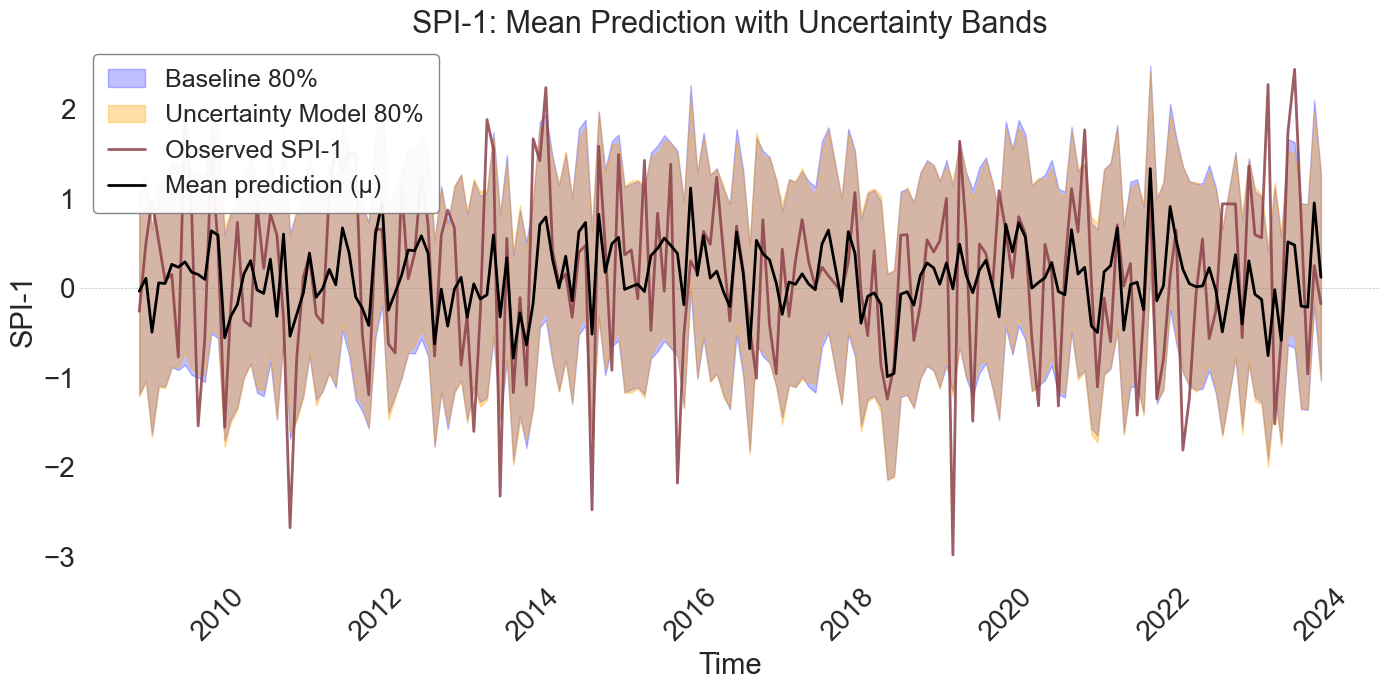


TIME SERIES PLOT SUMMARY

Data shown: Last 15 years (179 points)
Time range: 2008-12 to 2023-12

Baseline σ (constant): 0.8971 SPI units
CRPS model σ (mean): 0.8812 SPI units
CRPS model σ (std): 0.0401 SPI units

80% interval width:
  Baseline: 2.299 SPI units
  CRPS model (mean): 2.259 SPI units

Points outside 80% CI (plotted data):
  Baseline: 31/179 (17.3%)
  CRPS model: 33/179 (18.4%)


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy.stats import norm

# Get the data
y_true = data['y_true'].values
mu_pred = data['y_pred'].values  # Mean predictions from Stage 1
time_index = data['time'].values  # Time values
lr_crps_results = [r for r in results_list_crps 
                   if r['model'] == 'LinearRegression_CRPS' and r['config'] == 'Config_1_Top2']

if lr_crps_results:
    sigma_model = lr_crps_results[0]['sigma_predictions']

# Get baseline sigma (constant)
sigma_baseline = data['abs_error'].mean() * np.sqrt(np.pi / 2)
sigma_baseline_array = np.full(len(y_true), sigma_baseline)


z_80 = norm.ppf(0.90)   # ≈ 1.282

# Sort by time for proper plotting
sort_idx = np.argsort(time_index)
time_sorted = time_index[sort_idx]
y_true_sorted = y_true[sort_idx]
mu_pred_sorted = mu_pred[sort_idx]
sigma_model_sorted = sigma_model[sort_idx]
sigma_baseline_sorted = sigma_baseline_array[sort_idx]

# Convert time to datetime for better x-axis formatting
time_datetime = pd.to_datetime(time_sorted)

# Filter to last 15 years only
cutoff_date = time_datetime.max() - pd.DateOffset(years=15)
mask_15yr = time_datetime >= cutoff_date

time_datetime_15yr = time_datetime[mask_15yr]
y_true_15yr = y_true_sorted[mask_15yr]
mu_pred_15yr = mu_pred_sorted[mask_15yr]
sigma_model_15yr = sigma_model_sorted[mask_15yr]
sigma_baseline_15yr = sigma_baseline_sorted[mask_15yr]

# =============================================================================
# Create the plot
# =============================================================================
fig, ax = plt.subplots(figsize=(14, 7), facecolor='white')
ax.set_facecolor('white')

# Plot 80% confidence intervals
# Baseline (constant σ) - blue
ax.fill_between(time_datetime_15yr, 
                mu_pred_15yr - z_80 * sigma_baseline_15yr,
                mu_pred_15yr + z_80 * sigma_baseline_15yr,
                alpha=0.25, color='blue', label='Baseline 80%')

# CRPS model - orange
ax.fill_between(time_datetime_15yr, 
                mu_pred_15yr - z_80 * sigma_model_15yr,
                mu_pred_15yr + z_80 * sigma_model_15yr,
                alpha=0.35, color='orange', label='Uncertainty Model 80%')

# Plot actual values as line (behind the prediction) - darker, softer red
ax.plot(time_datetime_15yr, y_true_15yr, color='#8B4049', linewidth=2.0, 
        label='Observed SPI-1', zorder=2, alpha=0.85)

# Plot the mean prediction line (on top)
ax.plot(time_datetime_15yr, mu_pred_15yr, 'k-', linewidth=2.0, 
        label='Mean prediction (μ)', zorder=3)

# Formatting with larger fonts (+2 from previous)
ax.set_xlabel('Time', fontsize=21)
ax.set_ylabel('SPI-1', fontsize=21)
ax.set_title('SPI-1: Mean Prediction with Uncertainty Bands', fontsize=22)

# Format x-axis with larger tick labels
ax.xaxis.set_major_locator(mdates.YearLocator(2))  # Every 2 years
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.tick_params(axis='x', labelsize=20, rotation=45)
ax.tick_params(axis='y', labelsize=20)

# Add horizontal line at y=0 (SPI reference)
ax.axhline(y=0, color='gray', linestyle='--', linewidth=0.5, alpha=0.5)

# Legend with larger font (+3), background box with rounded corners
ax.legend(loc='upper left', fontsize=18, 
          frameon=True, fancybox=True, framealpha=0.95, 
          edgecolor='gray', facecolor='white',
          borderpad=0.6, handlelength=1.5)

# Grid
ax.grid(True, alpha=0.3)

plt.tight_layout()

# Save to thesis figures folder
out_dir = "../Thesis/Figures/"
plt.savefig(f'{out_dir}spi1_uncertainty_timeseries.png', dpi=150, bbox_inches='tight', facecolor='white')
print(f"Figure saved to: {out_dir}spi1_uncertainty_timeseries.png")

plt.show()

# =============================================================================
# Summary statistics
# =============================================================================
print("TIME SERIES PLOT SUMMARY")
print(f"\nData shown: Last 15 years ({len(y_true_15yr)} points)")
print(f"Time range: {time_datetime_15yr.min().strftime('%Y-%m')} to {time_datetime_15yr.max().strftime('%Y-%m')}")
print(f"\nBaseline σ (constant): {sigma_baseline:.4f} SPI units")
print(f"CRPS model σ (mean): {sigma_model_15yr.mean():.4f} SPI units")
print(f"CRPS model σ (std): {sigma_model_15yr.std():.4f} SPI units")
print(f"\n80% interval width:")
print(f"  Baseline: {2 * z_80 * sigma_baseline:.3f} SPI units")
print(f"  CRPS model (mean): {2 * z_80 * sigma_model_15yr.mean():.3f} SPI units")

# Count points outside intervals (for plotted data)
outside_baseline_80 = np.sum((y_true_15yr < mu_pred_15yr - z_80 * sigma_baseline_15yr) | 
                              (y_true_15yr > mu_pred_15yr + z_80 * sigma_baseline_15yr))
outside_model_80 = np.sum((y_true_15yr < mu_pred_15yr - z_80 * sigma_model_15yr) | 
                           (y_true_15yr > mu_pred_15yr + z_80 * sigma_model_15yr))

print(f"\nPoints outside 80% CI (plotted data):")
print(f"  Baseline: {outside_baseline_80}/{len(y_true_15yr)} ({100*outside_baseline_80/len(y_true_15yr):.1f}%)")
print(f"  CRPS model: {outside_model_80}/{len(y_true_15yr)} ({100*outside_model_80/len(y_true_15yr):.1f}%)")